# Сравнение суммы элементов векторов на CPU и GPU

В этой работе выполняется несколько экспериментов для векторов разных размеров. Для каждого размера измеряется время работы нескольких реализаций и вычисляется ускорение относительно наивной CPU-версии.

Также, в рамках личного интереса, проводились сравнения с функциями библиотек NumPy и PyTorch, т.к. по другим предметам я использовал их чаще собственной реализации

За CPU реализацию была взята стандартная формула суммы элементов векторов. Ничего не оптимизировано, поэтому далее буду называть её наивной

# 1. Импорт библиотек и задание размеров

Подключаем необходимые библиотеки и задаем список размеров векторов, на которых будет проводиться эксперимент.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from numba import cuda, float32

np.random.seed(42)

sizes = []
sizes = (np.linspace(1000, 1000000, 10)).astype(int)
dtype = np.float32

print("Размеры векторов:", sizes)
print("Numba CUDA доступна:", cuda.is_available())

Размеры векторов: [   1000  112000  223000  334000  445000  556000  667000  778000  889000
 1000000]
Numba CUDA доступна: True


# 2. Функции вычисления суммы

## 2.1. Функция наивного суммирования на CPU

Здесь используется последовательное сложение элементов вектора в одном цикле. Именно относительно этого варианта будет считаться ускорение.

In [2]:
def benchmark_cpu_sum(arr):
    start = time.perf_counter()
    
    total = 0.0
    for x in arr:
        total += float(x)
    
    end = time.perf_counter()
    return end - start, total

## 2.2. Функция суммирования через NumPy

Эта реализация использует готовую оптимизированную функцию `np.sum`, которая обычно работает значительно быстрее наивного варианта.

In [3]:
def benchmark_numpy_sum(arr):
    start = time.perf_counter()
    total = np.sum(arr)
    end = time.perf_counter()
    
    return end - start, total

## 2.3 CUDA

### 2.3.1 CUDA-ядро для Numba

В ядре каждый поток суммирует свою часть вектора, а внутри блока выполняется редукция в shared memory

In [4]:
@cuda.jit
def vector_sum_kernel(arr, block_sums):
    smem = cuda.shared.array(256, float32)

    tid = cuda.threadIdx.x
    idx = cuda.grid(1)
    stride = cuda.gridsize(1)

    local_sum = 0.0
    
    # Каждый поток суммирует свою часть массива
    for i in range(idx, arr.size, stride):
        local_sum += arr[i]

    smem[tid] = local_sum
    cuda.syncthreads()

    # Редукция внутри блока
    s = cuda.blockDim.x // 2
    while s > 0:
        if tid < s:
            smem[tid] += smem[tid + s]
        cuda.syncthreads()
        s //= 2

    # Запись частичной суммы блока
    if tid == 0:
        block_sums[cuda.blockIdx.x] = smem[0]

### 2.3.2 Функция суммирования через Numba CUDA

Векторы копируются на GPU, затем запускается CUDA-ядро, после чего частичные суммы объединяются на CPU. Если CUDA недоступна, функция возвращает пустой результат.

In [5]:
def benchmark_numba_cuda_sum(arr):
    if not cuda.is_available():
        return np.nan, None

    threadsperblock = 256
    blockspergrid = min(1024, max(1, (arr.size + threadsperblock - 1) // threadsperblock))

    d_arr = cuda.to_device(arr)
    d_block_sums = cuda.device_array(blockspergrid, dtype=arr.dtype)

    cuda.synchronize()
    start = time.perf_counter()

    vector_sum_kernel[blockspergrid, threadsperblock](d_arr, d_block_sums)

    block_sums = d_block_sums.copy_to_host()
    total = float(np.sum(block_sums, dtype=np.float64))

    cuda.synchronize()
    end = time.perf_counter()

    return end - start, total

## 2.4. Функция суммирования через PyTorch на GPU

В этом варианте используется библиотека PyTorch. Если CUDA недоступна, функция также возвращает пустой результат.

In [6]:
def benchmark_torch_cuda(arr):
    if not torch.cuda.is_available():
        return np.nan, None

    device = torch.device("cuda")
    arr_t = torch.tensor(arr, device=device)

    torch.cuda.synchronize()
    start = time.perf_counter()
    total_t = torch.sum(arr_t)
    torch.cuda.synchronize()
    end = time.perf_counter()

    C = total_t.cpu().numpy()
    return end - start, C

# 3. Прогрев GPU

Первый запуск на GPU может включать дополнительные накладные расходы. Поэтому перед основными измерениями выполняется небольшой прогрев.

In [7]:
# 4. Прогрев GPU

if cuda.is_available():
    test_vec = np.random.rand(4096).astype(dtype)
    benchmark_numba_cuda_sum(test_vec)
    print("Numba CUDA прогрета")

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Numba CUDA прогрета


# 4. Проведение экспериментов

Для каждого размера создаются случайные вектора, после чего измеряется время работы всех реализаций. Корректность проверяется относительно результата `NumPy`.

In [8]:
results = []

for size in sizes:
    print(f"Эксперимент для вектора длины {size}")

    vec = np.random.rand(size).astype(dtype)

    time_numpy, sum_numpy = benchmark_numpy_sum(vec)
    time_cpu, sum_cpu = benchmark_cpu_sum(vec)
    time_gpu, sum_gpu = benchmark_numba_cuda_sum(vec)
    time_torch, sum_torch = benchmark_torch_cuda(vec)

    results.append({
        "Размер": size,
        "Метод": "CPU",
        "Время, сек": time_cpu,
        "Ускорение": 1.0,
        "Корректность": np.allclose(sum_cpu, sum_numpy, atol=1e-4) if sum_cpu is not None else None
    })

    results.append({
        "Размер": size,
        "Метод": "NumPy",
        "Время, сек": time_numpy,
        "Ускорение": time_cpu / time_numpy if np.isfinite(time_numpy) and time_numpy > 0 else np.nan,
        "Корректность": True
    })

    results.append({
        "Размер": size,
        "Метод": "GPU (CUDA)",
        "Время, сек": time_gpu,
        "Ускорение": time_cpu / time_gpu if np.isfinite(time_gpu) and time_gpu > 0 else np.nan,
        "Корректность": np.isclose(sum_gpu, sum_numpy, rtol=1e-5, atol=1e-2) if sum_gpu is not None else None
    })

    results.append({
        "Размер": size,
        "Метод": "PyTorch GPU",
        "Время, сек": time_torch,
        "Ускорение": time_cpu / time_torch if np.isfinite(time_torch) and time_torch > 0 else np.nan,
        "Корректность": np.allclose(sum_torch, sum_numpy, atol=1e-3) if sum_torch is not None else None
    })

results_df = pd.DataFrame(results)
results_df["Время, сек"] = results_df["Время, сек"].round(6)
results_df["Ускорение"] = results_df["Ускорение"].round(2)

results_df

Эксперимент для вектора длины 1000
Эксперимент для вектора длины 112000
Эксперимент для вектора длины 223000
Эксперимент для вектора длины 334000
Эксперимент для вектора длины 445000
Эксперимент для вектора длины 556000
Эксперимент для вектора длины 667000
Эксперимент для вектора длины 778000


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Эксперимент для вектора длины 889000
Эксперимент для вектора длины 1000000


,Размер,Метод,"Время, сек",Ускорение,Корректность
0,1000,CPU,0.000075,1.00,True
1,1000,NumPy,0.000033,2.27,True
2,1000,GPU (CUDA),0.000593,0.13,True
3,1000,PyTorch GPU,0.013081,0.01,True
4,112000,CPU,0.006382,1.00,True
5,112000,NumPy,0.000039,163.64,True
6,112000,GPU (CUDA),0.000261,24.48,True
7,112000,PyTorch GPU,0.000064,99.26,True
8,223000,CPU,0.012394,1.00,True
9,223000,NumPy,0.000064,194.26,True


# 5. Построение графиков

Первый блок графиков показывает зависимость времени выполнения от размера вектора, второй - ускорение относительно CPU, третий - сравнение без CPU.

## 5.1 Все

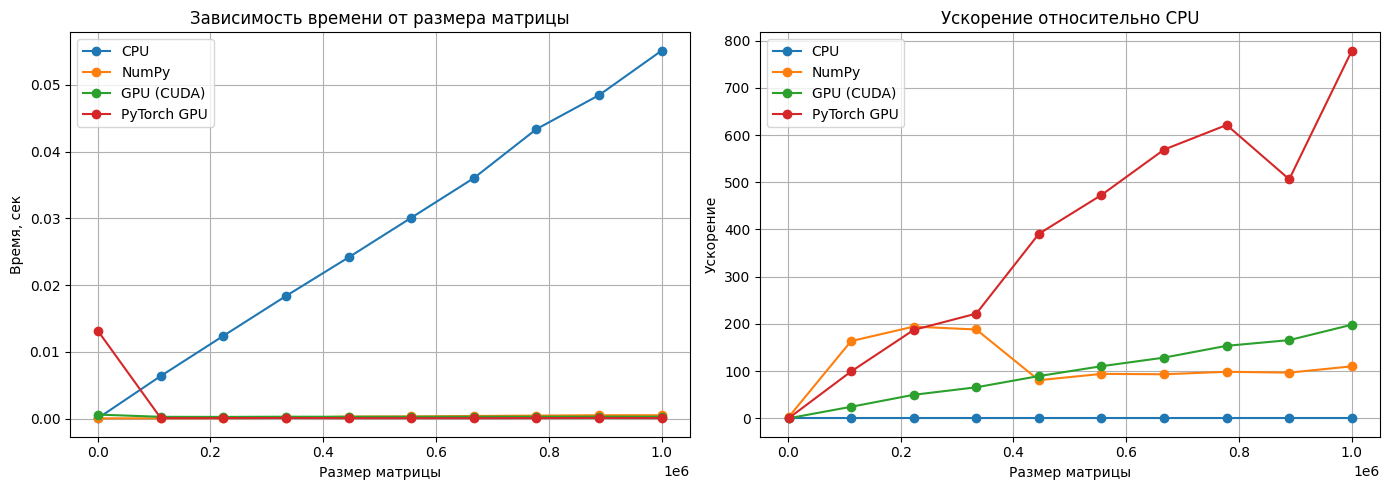

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for method in results_df["Метод"].unique():
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Время, сек"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Время, сек")
plt.title("Зависимость времени от размера матрицы")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for method in results_df["Метод"].unique():
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Ускорение"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Ускорение")
plt.title("Ускорение относительно CPU")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 5.2 CPU VS GPU

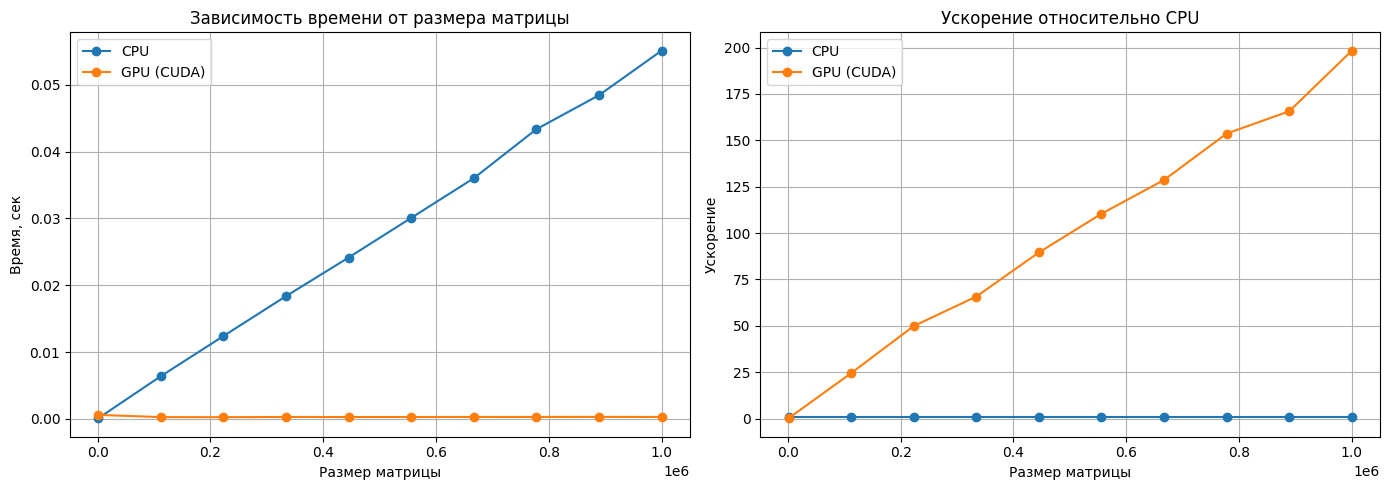

In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for method in results_df["Метод"].unique():
    if method == "PyTorch GPU":
        continue
    if method == "NumPy":
        continue
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Время, сек"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Время, сек")
plt.title("Зависимость времени от размера матрицы")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for method in results_df["Метод"].unique():
    if method == "PyTorch GPU":
        continue
    if method == "NumPy":
        continue
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Ускорение"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Ускорение")
plt.title("Ускорение относительно CPU")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 5.3 Все без CPU

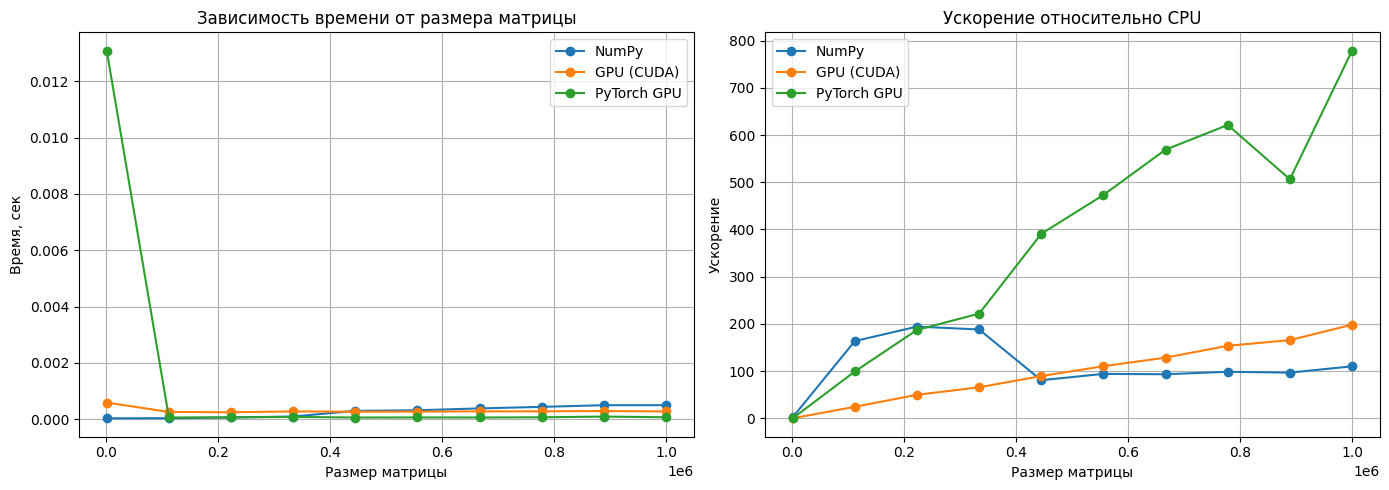

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for method in results_df["Метод"].unique():
    if method != "CPU":
        part = results_df[results_df["Метод"] == method]
        plt.plot(part["Размер"], part["Время, сек"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Время, сек")
plt.title("Зависимость времени от размера матрицы")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for method in results_df["Метод"].unique():
    if method != "CPU":
        part = results_df[results_df["Метод"] == method]
        plt.plot(part["Размер"], part["Ускорение"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Ускорение")
plt.title("Ускорение относительно CPU")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 6. Вывод

В результате проведена серия экспериментов для нескольких размеров векторов. Для каждой реализации измерено время работы, рассчитано ускорение относительно наивной CPU-версии и построены таблицы и графики для наглядного сравнения.

PyTorch на GPU, как и ожидалось, снова показал наилучший результат, за исключением первых 3 экспериментов (можно сослаться на маленький размер векторов). Однако NumPy в этот раз на бОльших размерах показал себя хуже распаралелленной версии наивного вычисления.

В сравнении параллельной и обычной версии, параллельная оказалась заметно лучше, что можно заметить по 1 и 2 блокам графиков